# Run plaquette-rep circuits with AerSimulator

The same thing can be done with JAX now with apply_u

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1,2,3,4,5,6,7'
import time
import logging
from concurrent.futures import ThreadPoolExecutor
import numpy as np
import h5py
import matplotlib.pyplot as plt
import jax
from jax.experimental.sparse import BCOO
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit_aer import AerSimulator
from heavyhex_qft.triangular_z2 import TriangularZ2Lattice
# from heavyhex_qft.subspace import subspace_projection, subspace_ground_state
from qiimk.circuits import make_plaquette_circuits

logging.basicConfig(level=logging.WARNING)
logging.getLogger('skqd').setLevel(logging.INFO)

jax.config.update('jax_enable_x64', True)

In [2]:
def clean_array(arr):
    cleaned = np.where(np.isclose(arr.real, 0.), 0., arr.real).astype(arr.dtype)
    if arr.dtype == np.complex128:
        cleaned += 1.j * np.where(np.isclose(arr.imag, 0.), 0., arr.imag)
    return cleaned

In [3]:
# lattice = TriangularZ2Lattice('''
#   * * *
#  * * * *
# * * * * *
#  * * * *
#   * * *
# ''')
# lattice = TriangularZ2Lattice('''
#  * *
# * * *
#  * *
# ''')
lattice = TriangularZ2Lattice('''
 * * * *
* * * *
 * * * *
* * * *
 * * * *
* * * *
''')
dual_lattice = lattice.plaquette_dual()

print(lattice.num_links, lattice.num_plaquettes)

plaquette_energy = 0.7
max_steps = 8
shots = 100000
num_experiments = 1

53 30


In [4]:
delta_t = Parameter(r'$\Delta t$')
step_circuits = make_plaquette_circuits(dual_lattice, plaquette_energy, delta_t)
trotter_step = step_circuits[0]
measure = step_circuits[-1]

# hamiltonian = dual_lattice.make_hamiltonian(plaquette_energy)
# ground_energy, ground_state = subspace_ground_state(BCOO.from_scipy_sparse(hamiltonian.to_matrix(sparse=True)))

In [5]:
simulator = AerSimulator(method='statevector', device='GPU', max_parallel_experiments=0, num_threads_per_device=16)

In [ ]:
dtvals = np.linspace(0.1, 0.6, 6)
samples = np.empty((dtvals.shape[0], max_steps, num_experiments), dtype=object)
for idt, dtval in enumerate(dtvals):
    step_circ = trotter_step.assign_parameters({delta_t: dtval}, inplace=False)
    circuits = []
    circuit = step_circ.copy_empty_like()
    for _ in range(max_steps):
        circuit.compose(step_circ, inplace=True)
        circuits.append(circuit.compose(measure, inplace=False))

    result = simulator.run(circuits * num_experiments, shots=shots).result()
    for iexp in range(num_experiments):
        samples[idt, 0, iexp] = set(result.get_counts(max_steps * iexp).keys())
        for istep in range(1, max_steps):
            samples[idt, istep, iexp] = samples[idt, istep - 1, iexp] | set(result.get_counts(max_steps * iexp + istep).keys())

: 

In [ ]:
[len(samples[3, i, 0]) for i in range(max_steps)]

[18603, 37256, 39628, 47148, 58507, 61664, 68087, 76013]

In [9]:
proj_dimensions = np.empty((max_steps, num_experiments), dtype=int)
proj_coverage = np.empty((max_steps, num_experiments))
proj_energies = np.empty((max_steps, num_experiments))

LOG = logging.getLogger('skqd')

def skqd(krylov_dim, i_exp):
    indices = set()
    for istep in range(krylov_dim):
        indices |= set(samples[istep][max_steps - krylov_dim])
    indices = np.array(list(indices))
    LOG.info('D%d: %d configurations', krylov_dim, indices.shape[0])
    proj_dimensions[krylov_dim - 1, i_exp] = indices.shape[0]
    bin_indices = (indices[:, None] >> np.arange(lattice.num_plaquettes)[None, ::-1]) % 2

    proj_coverage[krylov_dim - 1, i_exp] = np.sum(np.square(np.abs(ground_state[indices])))
    with jax.default_device(jax.devices()[krylov_dim % len(jax.devices())]):
        start = time.time()
        hproj = subspace_projection(hamiltonian, bin_indices)
        end = time.time()
        LOG.info('D%d: %f seconds to project', krylov_dim, end - start)
        start = end
        proj_ground_energy, _ = subspace_ground_state(hproj)
        end = time.time()
        LOG.info('D%d: %f seconds to diagonalize', krylov_dim, end - start)
    proj_energies[krylov_dim - 1, i_exp] = proj_ground_energy

with ThreadPoolExecutor() as executor:
    for i_exp in range(num_experiments):
        futures = [executor.submit(skqd, dim, i_exp) for dim in range(1, max_steps + 1)]
        [future.result() for future in futures]
# [skqd(dim, 0) for dim in range(1, max_steps + 1)]

INFO:skqd:D1: 177 configurations
INFO:skqd:D2: 848 configurations
INFO:skqd:D3: 2518 configurations
INFO:skqd:D4: 4979 configurations
INFO:skqd:D5: 7992 configurations
INFO:skqd:D6: 10675 configurations
INFO:skqd:D7: 13236 configurations
INFO:skqd:D8: 15124 configurations
INFO:skqd:D10: 17852 configurations
INFO:skqd:D11: 18739 configurations
INFO:skqd:D9: 16616 configurations
INFO:skqd:D12: 19843 configurations
INFO:skqd:D13: 20905 configurations
INFO:skqd:D14: 21935 configurations
INFO:skqd:D16: 24637 configurations
INFO:skqd:D15: 23133 configurations
INFO:skqd:D1: 3.721891 seconds to project
INFO:skqd:D3: 6.353914 seconds to project
INFO:skqd:D2: 6.415713 seconds to project
INFO:skqd:D9: 6.161692 seconds to project
INFO:skqd:D1: 3.963463 seconds to diagonalize
INFO:skqd:D13: 8.128448 seconds to project
INFO:skqd:D12: 8.166866 seconds to project
INFO:skqd:D5: 8.372223 seconds to project
INFO:skqd:D6: 8.270741 seconds to project
INFO:skqd:D14: 8.179816 seconds to project
INFO:skqd:D11

In [10]:
dirname = '/data/iiyama/heavyhex-qft/plaquette_sim'
try:
    os.makedirs(dirname)
except FileExistsError:
    pass

filename = f'p{lattice.num_plaquettes}_k{kval:.2f}_dt{dtval:.2f}_maxdim{max_steps}_shots{shots}.h5'
with h5py.File(os.path.join(dirname, filename), 'w') as out:
    out.create_dataset('configuration', data=lattice.configuration)
    out.create_dataset('kval', data=kval)
    out.create_dataset('dtval', data=dtval)
    out.create_dataset('max_steps', data=max_steps)
    out.create_dataset('shots', data=shots)
    out.create_dataset('num_experiments', data=num_experiments)
    out.create_dataset('ground_energy', data=ground_energy)
    out.create_dataset('ground_state', data=ground_state)
    out.create_dataset('statevectors', data=np.array([np.asarray(result_data[f'step{istep}'])
                                                      for istep in range(max_steps)]))
    out.create_dataset('proj_dimensions', data=proj_dimensions)
    out.create_dataset('proj_coverage', data=proj_coverage)
    out.create_dataset('proj_energies', data=proj_energies)

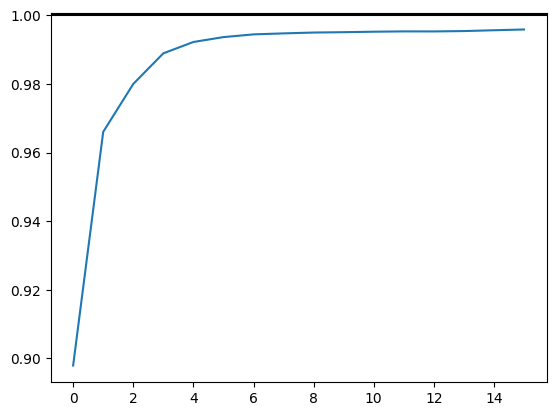

In [11]:
plt.plot(np.arange(max_steps), np.mean(proj_coverage, axis=1))
plt.axhline(1., color='k')

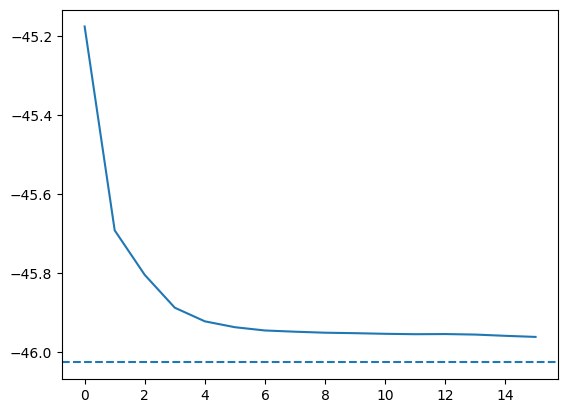

In [12]:
plt.plot(np.arange(max_steps), np.mean(proj_energies, axis=1))
plt.axhline(ground_energy, linestyle='--')

In [13]:
ground_probs = np.square(np.abs(ground_state))
sort_idx = np.argsort(-ground_probs)

In [14]:
sort_idx[:10]

array([      0,     256,    1024,   65536,   32768,    8192,     128,
       1048576,  262144,   16384])

In [15]:
ground_probs[sort_idx[:10]]

array([0.49844583, 0.01424924, 0.01424924, 0.01424923, 0.01424923,
       0.01424923, 0.01424923, 0.01421541, 0.01421541, 0.01421541])